# FLUX Image-to-Image Canny Batch 🗒️🖼️

⚠️ **Remember to copy this notebook in your Drive and rename.**

🤗 This notebook uses [Hugging Face Diffusers](https://huggingface.co/docs/diffusers/en/index) to create pipelines for tasks such as image generation.

*Workflows for IAAC MaCDA GenAI  (Apr - Jun 2026) taught by [James McBennett](https://www.linkedin.com/in/mcbennett/) and [Aymeric Brouez](https://www.linkedin.com/in/aymeric-brouez/)*

*With special thanks to past faculty [Nono Martínez Alonso](https://youtube.com/NonoMartinezAlonso).*

***Workflow requires A100 runtime**


### Mount Drive

In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Hugging Face Token

In [ ]:
# Sign up at Hugging Face and create a "Read" access token (not the default "Fine-Grained" token).
# Click the 🔑 "Secrets" icon in the left sidebar.
# Enable Notebook Access, Set the Name to "HF_TOKEN", Paste your token as the Value

from google.colab import userdata
hf_token = userdata.get("HF_TOKEN")

## Setup

In [ ]:
%cd /content
!rm -rf iaac_genai
!git clone https://github.com/jamesmcbennett/iaac_genai
%cd /content/iaac_genai/

/content
Cloning into 'creative-image-generation'...
remote: Enumerating objects: 137, done.
remote: Counting objects: 100% (137/137), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 137 (delta 68), reused 104 (delta 39), pack-reused 0 (from 0)
Receiving objects: 100% (137/137), 33.36 KiB | 1.33 MiB/s, done.
Resolving deltas: 100% (68/68), done.
/content/creative-image-generation


In [ ]:
import sys
sys.path.append('/content/iaac_genai')

In [ ]:
!pip install -q -r requirements.txt --quiet > /dev/null 2>&1

In [ ]:
from config import Config
from utils import set_image_path, save_image, save_yml, save_svg, save_gif, export_montage
from IPython.display import Image as IPythonImage
import torch

from diffusers.utils import load_image
from PIL import Image
import numpy as np
import cv2
import os

## Set Directories

In [ ]:
# Input directory is a folder directory that will input all images inside that directory
# dataset from https://cmp.felk.cvut.cz/~tylecr1/facade/
INPUT_DIR = '/content/drive/MyDrive/iaac_genai/inputs/crow_museum'
Config.OUTPUT_DIR = '/content/drive/MyDrive/iaac_genai/outputs'

## Canny

In [ ]:
images = []
resolution = 768

for filename in os.listdir(INPUT_DIR ):
  if filename.lower().endswith((".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tiff")):
    image_path = os.path.join(INPUT_DIR , filename)
    image = load_image(image_path)

    #Square
    w, h = image.size
    square_dim = min(w, h)
    image = image.crop((0, 0, square_dim, square_dim))

    #Resize
    max_dim = resolution
    image = image.resize((max_dim, max_dim), Image.LANCZOS)

    images.append(image)

In [ ]:
input_images_np = []

for image in images:
  input_image_np = np.array(image)
  display(input_image_np)
  input_images_np.append(input_image_np)
  print("\n")

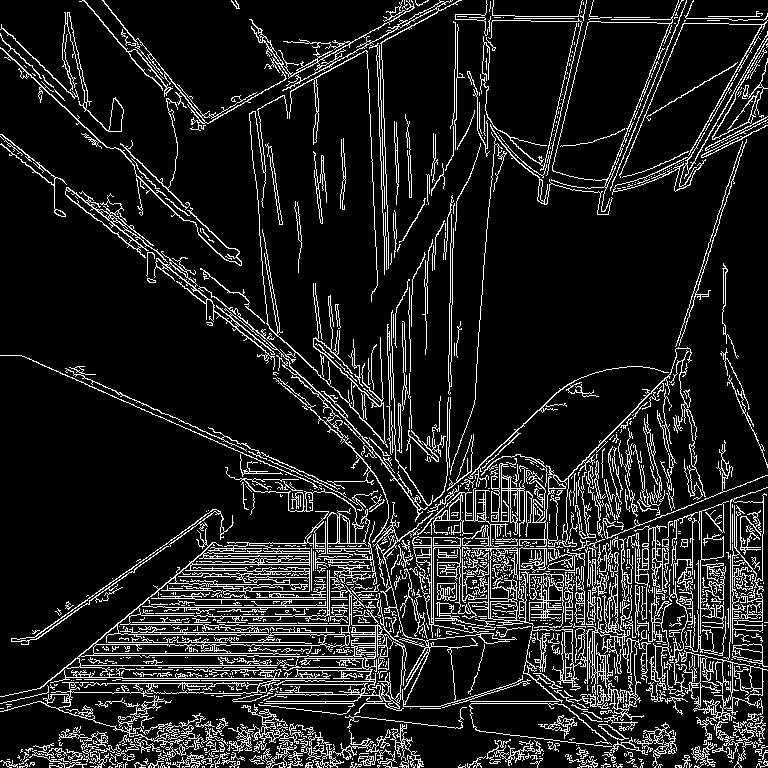

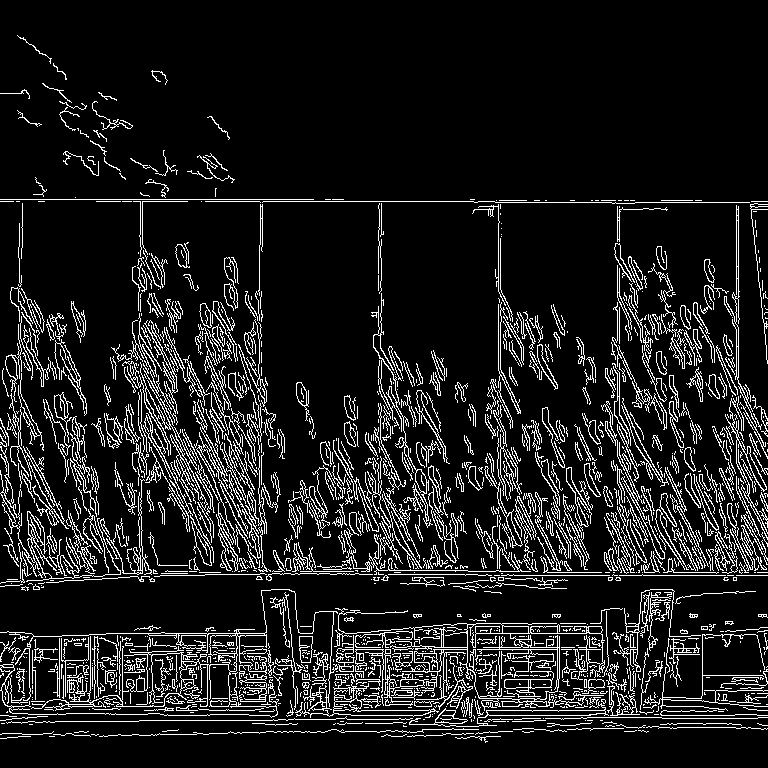

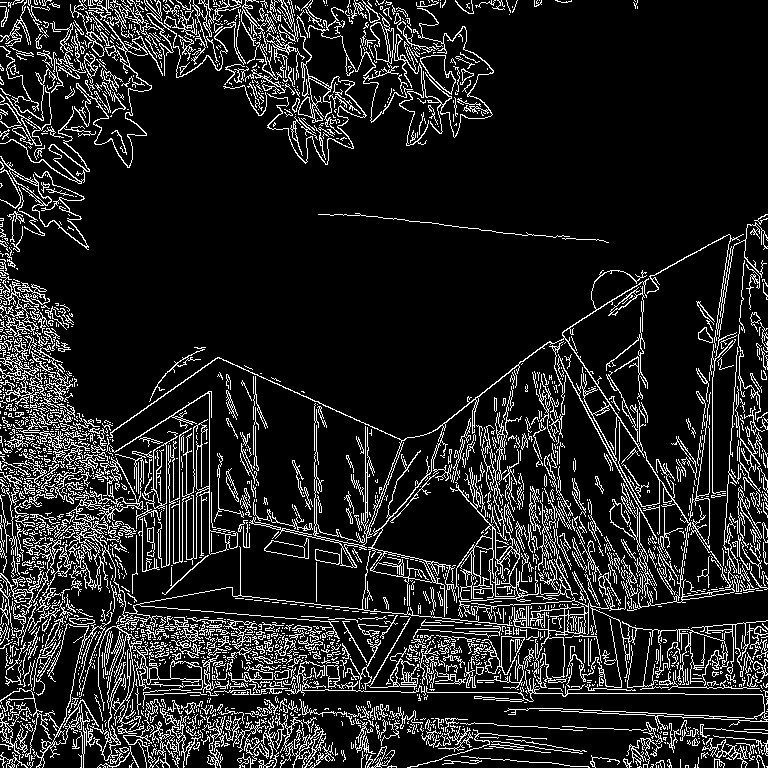

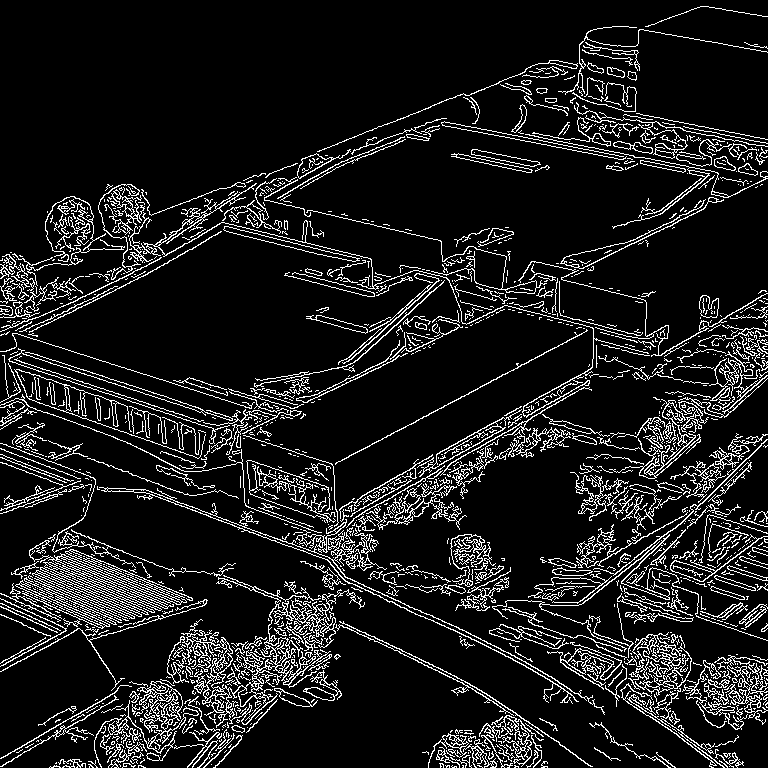

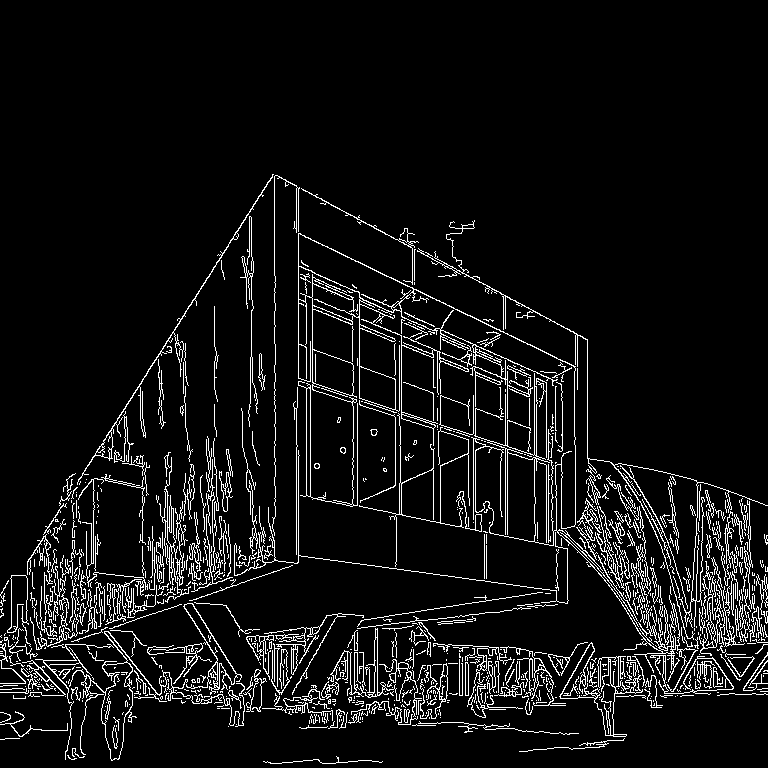

In [ ]:
canny_images = []

for input_image_np in input_images_np:
  # Get canny image
  canny_image = cv2.Canny(input_image_np, 10, 100)
  canny_image = canny_image[:, :, None]
  canny_image = np.concatenate([canny_image, canny_image, canny_image], axis=2)
  canny_image = Image.fromarray(canny_image)

  # download an image
  display(canny_image)
  canny_images.append(canny_image)
  print("\n")

## Load pipeline

Load a pipeline with Hugging Face Diffusers.

In [ ]:
# Create pipeline (2 min load on A100)
from diffusers import FluxControlNetPipeline, FluxControlNetModel

base_model = 'black-forest-labs/FLUX.1-dev'
controlnet_model_union = 'Shakker-Labs/FLUX.1-dev-ControlNet-Union-Pro-2.0'
controlnet = FluxControlNetModel.from_pretrained(controlnet_model_union, torch_dtype=torch.bfloat16)
pipe = FluxControlNetPipeline.from_pretrained(base_model, controlnet=controlnet, torch_dtype=torch.bfloat16)
pipe.to("cuda")

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/4.28G [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/536 [00:00<?, ?B/s]

Fetching 23 files:   0%|          | 0/23 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/782 [00:00<?, ?B/s]

...

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

FluxControlNetPipeline {
  "_class_name": "FluxControlNetPipeline",
  "_diffusers_version": "0.33.1",
  "_name_or_path": "black-forest-labs/FLUX.1-dev",
  "controlnet": [
    "diffusers",
    "FluxControlNetModel"
  ],
  "feature_extractor": [
    null,
    null
  ],
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "FlowMatchEulerDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "T5EncoderModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "T5TokenizerFast"
  ],
  "transformer": [
    "diffusers",
    "FluxTransformer2DModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

## Config

You can override parameters here.

In [ ]:
Config.PROMPT = 'A contemporary wooden mass-timber building, surrounded by cherry blossom trees in full bloom. Under a clear blue sky.'
Config.SEED = 7797676568
Config.STEPS = 28

Config.AUTHOR = 'James'
Config.ALGO_TYPE = 'Image-to-Image'
Config.ALGO_NAME = 'Flux.1 Dev Canny Batch'

Config.check()

Config OK.


## Generate

In [ ]:
frames = []

for i, canny_image in enumerate(canny_images):
  # Generate
  controlnet_conditioning_scale=0.7
  control_guidance_end=0.8
  guidance_scale=3.5

  generator = torch.Generator(Config.TORCH_DEVICE).manual_seed(Config.SEED)
  image = pipe(Config.PROMPT, control_image=canny_image, height=resolution, width=resolution, controlnet_conditioning_scale=controlnet_conditioning_scale, control_guidance_end=control_guidance_end, num_inference_steps=Config.STEPS, guidance_scale=guidance_scale, max_sequence_length=256, generator=generator).images[0]
  set_image_path()

  display(image)

  # what to add to frames to be used in gif / montage below
  frames.append(images[i])
  frames.append(canny_image)
  frames.append(image)

  # Save yml metadata
  save_yml(pipe)

  # Save image
  save_image(image)

  # Save svg parameters image
  save_svg({
      'SEED': Config.SEED,
      'STEPS': Config.STEPS,
      'Google Colab': '',
  })

## Gif

In [ ]:
Config.FPS = 1
gif_path = save_gif(frames)
IPythonImage(filename=gif_path)

## Montage

In [ ]:
### Cell be removed when export_montage is updated on Github

import imageio
import os

def export_montage(frames, columns):

    # Calculate the total number of frames and the number of frames per row
    total_frames = len(frames)
    frames_per_row = min(total_frames, columns)

    # Calculate the width and height of each frame in the montage
    frame_width, frame_height = frames[0].size  # Assuming all frames have the same size
    montage_width = frame_width * frames_per_row
    montage_height = frame_height * ((total_frames - 1) // frames_per_row + 1)

    # Create a blank image to hold the montage
    montage = np.zeros((montage_height, montage_width, 3), dtype=np.uint8)

    # Fill the montage with frames
    for idx, frame in enumerate(frames):
        row_idx = idx // frames_per_row
        col_idx = idx % frames_per_row
        start_x = col_idx * frame_width
        start_y = row_idx * frame_height
        end_x = start_x + frame_width
        end_y = start_y + frame_height
        montage[start_y:end_y, start_x:end_x, :] = np.array(frame)

    # Save the montage as a single image
    set_image_path()
    montage_path = f"{Config.IMAGE_PATH.replace('.png', '_montage.png')}"
    imageio.imwrite(montage_path, montage)

    return montage_path

In [ ]:
columns = 3

montage_path = export_montage(frames, columns)
IPythonImage(filename=montage_path)

## Disconnect

In [ ]:
from google.colab import runtime
runtime.unassign()